# Predicción de la Vida Útil de Baterías de Vehículos Eléctricos usando RNN

Lucho Feb| 2023 <br>
Tout Doucement by Feist

Se sometió a un conjunto de baterías de iones de litio a diferentes perfiles operativos (carga, descarga e impedancia) a diversas temperaturas. La medición de impedancia se llevó a cabo mediante espectroscopía de impedancia electroquímica (EIS) en distintas frecuencias.

Los ciclos repetidos de carga y descarga provocan un envejecimiento acelerado de las baterías, mientras que las mediciones de impedancia ofrecen información sobre los parámetros internos de la batería que cambian a medida que avanza el envejecimiento. Los experimentos se detuvieron cuando las baterías alcanzaron los criterios de fin de vida útil (EOL, por sus siglas en inglés).

Estos conjuntos de datos pueden utilizarse para predecir tanto la carga restante (en un ciclo de descarga determinado) como la vida útil remanente (RUL).

Dataset: https://www.kaggle.com/datasets/patrickfleith/nasa-battery-dataset?resource=download

## Import Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# keras
from tensorflow.keras.models import Sequential
from keras.layers import (BatchNormalization, Conv2D, Dense, Dropout, Flatten,
                          MaxPool2D, MaxPooling2D, Input)

# sklearn
from sklearn.preprocessing import MinMaxScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,mean_squared_log_error
import pickle


## Import Dataset

In [2]:
df = pd.read_csv(r"metadata.csv")
df_raw = df.copy()
df.head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   type                 7565 non-null   object
 1   start_time           7565 non-null   object
 2   ambient_temperature  7565 non-null   int64 
 3   battery_id           7565 non-null   object
 4   test_id              7565 non-null   int64 
 5   uid                  7565 non-null   int64 
 6   filename             7565 non-null   object
 7   Capacity             2794 non-null   object
 8   Re                   1956 non-null   object
 9   Rct                  1956 non-null   object
dtypes: int64(3), object(7)
memory usage: 591.1+ KB


In [4]:
df.describe()

,ambient_temperature,test_id,uid
count,7565.000000,7565.000000,7565.000000
mean,20.017713,176.012558,3783.000000
std,11.082914,152.174147,2183.971726
min,4.000000,0.000000,1.000000
25%,4.000000,55.000000,1892.000000
50%,24.000000,129.000000,3783.000000
75%,24.000000,255.000000,5674.000000
max,44.000000,615.000000,7565.000000


In [5]:
df.isna().sum()

type                      0
start_time                0
ambient_temperature       0
battery_id                0
test_id                   0
uid                       0
filename                  0
Capacity               4771
Re                     5609
Rct                    5609
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df = df.drop(columns=['start_time','battery_id','test_id','uid','filename'])
df.head()

,type,ambient_temperature,Capacity,Re,Rct
0,discharge,4,1.6743047446975208,NaN,NaN
1,impedance,24,NaN,0.05605783343888099,0.20097016584458333
2,charge,4,NaN,NaN,NaN
3,impedance,24,NaN,0.05319185850921101,0.16473399914864734
4,discharge,4,1.5243662105099023,NaN,NaN


In [8]:
df['Re'] = pd.to_numeric(df['Re'], errors='coerce')
df['Rct'] = pd.to_numeric(df['Rct'], errors='coerce')
df['Capacity'] = pd.to_numeric(df['Capacity'], errors='coerce')

# Rellenar los valores faltantes en 'Re', 'Rct' y 'Capacity' con sus respectivas medias
df['Re'] = df['Re'].fillna(df['Re'].mean())
df['Rct'] = df['Rct'].fillna(df['Rct'].mean())
df['Capacity'] = df['Capacity'].fillna(df['Capacity'].mean())

df.head()

,type,ambient_temperature,Capacity,Re,Rct
0,discharge,4,1.674305,-4.976500e+11,1.055903e+12
1,impedance,24,1.326543,5.605783e-02,2.009702e-01
2,charge,4,1.326543,-4.976500e+11,1.055903e+12
3,impedance,24,1.326543,5.319186e-02,1.647340e-01
4,discharge,4,1.524366,-4.976500e+11,1.055903e+12


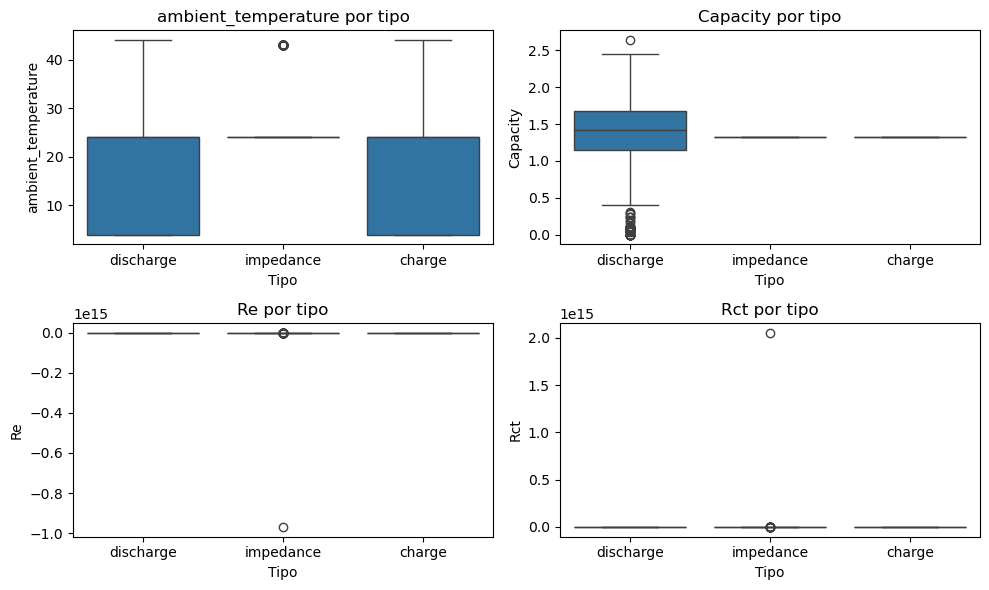

In [9]:
# Columnas a graficar
columnas = ['ambient_temperature', 'Capacity', 'Re', 'Rct']

# Crear una figura con subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()

# Graficar cada variable con respecto a 'type'
for i, col in enumerate(columnas):
    sns.boxplot(data=df, x='type', y=col, ax=axes[i])
    axes[i].set_title(f'{col} por tipo')
    axes[i].set_xlabel('Tipo')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

### Modelo

In [10]:
label_encoder = LabelEncoder()

df['type'] = label_encoder.fit_transform(df['type'])

In [11]:
# Características (X) - Todas las columnas excepto 'ambient_temperature'
X = df.drop(columns=['ambient_temperature'])

# Variable objetivo (y) - Columna 'ambient_temperature'
y = df['ambient_temperature']

# Dividir los datos en 80% para entrenamiento y 20% para prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Mostrar las dimensiones de los conjuntos divididos
print(f'Dimensión de X_train: {X_train.shape}')
print(f'Dimensión de X_test: {X_test.shape}')

Dimensión de X_train: (6052, 4)
Dimensión de X_test: (1513, 4)


In [12]:
# Inicializar el MinMaxScaler
scaler = MinMaxScaler()

# Ajustar y transformar los datos de entrenamiento, luego transformar los datos de prueba
X_train_escalado = scaler.fit_transform(X_train)
X_test_escalado = scaler.transform(X_test)

# Verificar los datos escalados
print(f'X_train escalado: \n{X_train_escalado[:5]}')

X_train escalado: 
[[1.00000000e+00 5.02450122e-01 9.99999999e-01 1.98111482e-10]
 [5.00000000e-01 4.55998175e-01 0.00000000e+00 1.00000000e+00]
 [5.00000000e-01 3.60527766e-02 0.00000000e+00 1.00000000e+00]
 [0.00000000e+00 5.02450122e-01 0.00000000e+00 1.00000000e+00]
 [5.00000000e-01 5.35874070e-01 0.00000000e+00 1.00000000e+00]]


In [13]:
# Inicializar el modelo de red neuronal artificial (ANN)
modelo = Sequential()

# Capa de entrada y primera capa oculta con 64 unidades y activación ReLU
modelo.add(Input(shape=(X_train_escalado.shape[1],)))
modelo.add(Dense(units=64, activation='relu'))

# Añadir una capa Dropout con tasa del 20%
modelo.add(Dropout(0.2))

# Segunda capa oculta con 32 unidades y activación ReLU
modelo.add(Dense(units=32, activation='relu'))

# Añadir otra capa Dropout
modelo.add(Dropout(0.2))

# Capa de salida con 1 unidad (para salida de regresión), usando activación lineal
modelo.add(Dense(units=1, activation='linear'))

# Compilar el modelo con optimizador Adam y función de pérdida de error cuadrático medio (MSE)
modelo.compile(optimizer='adam', loss='mean_squared_error')

# Mostrar el resumen de la arquitectura del modelo
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Entrenar el modelo con los datos de entrenamiento, utilizando los datos de prueba para validación
historial = modelo.fit(X_train_escalado, y_train, epochs=150, batch_size=32, validation_data=(X_test_escalado, y_test))

Epoch 1/150
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 279.1653 - val_loss: 80773.0234
Epoch 2/150
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 117.8114 - val_loss: 62767.0391
Epoch 3/150
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 113.6092 - val_loss: 49925.6836
Epoch 4/150
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 110.9835 - val_loss: 41972.1836
Epoch 5/150
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 109.5201 - val_loss: 30631.2949
Epoch 6/150
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 107.1221 - val_loss: 17084.0527
Epoch 7/150
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 106.0987 - val_loss: 11261.4775
Epoch 8/150
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 105.8079 - val_loss: 6772.1040
Epoch 9/150
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 104.5214 - val_loss: 3305.1807
Epoch 10/150
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 103.1478 - val_loss: 2328.6387
Epoch 11/150
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 101.6711 -

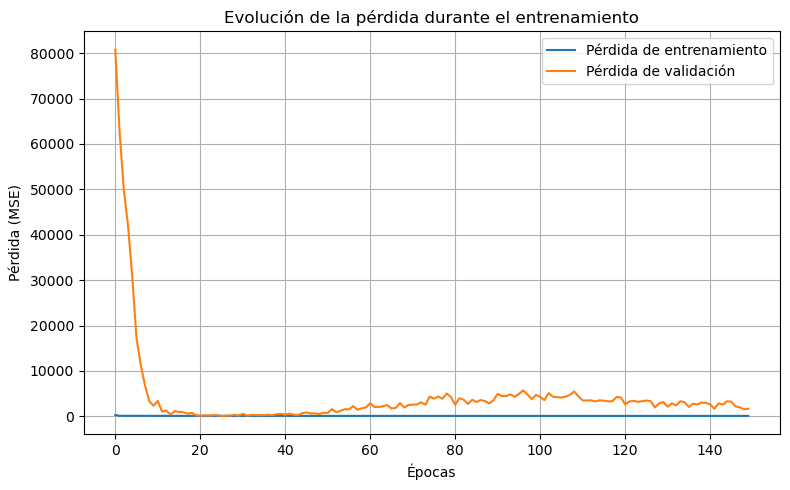

In [15]:
# Graficar la pérdida del entrenamiento y validación a lo largo de las épocas
plt.figure(figsize=(8, 5))
plt.plot(historial.history['loss'], label='Pérdida de entrenamiento')
plt.plot(historial.history['val_loss'], label='Pérdida de validación')
plt.title('Evolución de la pérdida durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
# Evaluar el modelo con los datos de prueba
error_cuadratico_medio = modelo.evaluate(X_test_escalado, y_test)

# Imprimir el Error Cuadrático Medio (MSE)
print(f'Error Cuadrático Medio en el conjunto de prueba: {error_cuadratico_medio}')

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1688.3463
Error Cuadrático Medio en el conjunto de prueba: 1688.3463134765625


In [17]:
# Realizar predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test_escalado)
# Aplanar los arrays por si vienen como matrices (opcional, por claridad)
y_pred = y_pred.flatten()
y_test_flat = y_test.to_numpy().flatten()

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


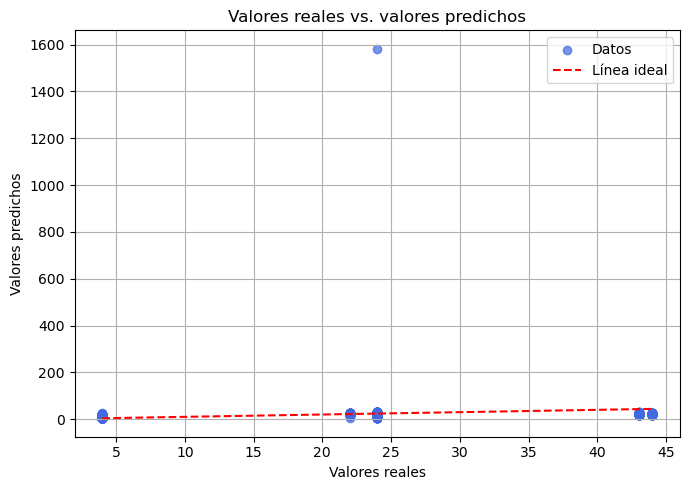

In [18]:
# Crear el gráfico
plt.figure(figsize=(7, 5))
plt.scatter(y_test_flat, y_pred, alpha=0.7, color='royalblue', label='Datos')
plt.plot([y_test_flat.min(), y_test_flat.max()], [y_test_flat.min(), y_test_flat.max()], color='red', linestyle='--', label='Línea ideal')
plt.xlabel('Valores reales')
plt.ylabel('Valores predichos')
plt.title('Valores reales vs. valores predichos')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Prediccion

In [19]:
def predict_battery_life(type_discharge, Capacity, Re, Rct, label_encoder, scaler, model):
    # Codificar la característica categórica
    type_discharge_encoded = label_encoder.transform([type_discharge])[0]
    
    # Preparar el vector de entrada como array
    X_input = np.array([[type_discharge_encoded, Capacity, Re, Rct]])
    
    # Convertir a DataFrame con columnas correctas para evitar warnings
    columnas = ['type', 'Capacity', 'Re', 'Rct']
    X_input_df = pd.DataFrame(X_input, columns=columnas)
    
    # Escalar usando el DataFrame
    X_input_scaled = scaler.transform(X_input_df)
    
    # Predecir la vida útil
    predicted_battery_life = model.predict(X_input_scaled)
    
    return predicted_battery_life[0]

In [20]:
tipo_descarga = 'discharge'  
capacidad = 1.674305         
Re = -4.976500e+11            
Rct = 1.055903e+12            

predicted_battery_life  = predict_battery_life(tipo_descarga, capacidad, Re, Rct, label_encoder, scaler, modelo)

print(f"Vida útil de batería predicha: {predicted_battery_life}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Vida útil de batería predicha: [26.06692]


### Guardar Modelo

In [21]:
# Save the model, scaler, and label encoder to disk
with open('battery_life_model.pkl', 'wb') as model_file:
    pickle.dump(modelo, model_file)

with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

with open('label_encoder.pkl', 'wb') as le_file:
    pickle.dump(label_encoder, le_file)